# Computer Exercise 3.2 - Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.2 Newton's Method - *Failure modes: divergence near inflection points*
> **풀이 일자**: Day 12
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** Construct examples where Newton's method **fails to converge** even though
> the function has a simple real root and the derivative is nonzero everywhere.
> In particular, demonstrate divergence for $f(x) = \arctan x$ when the initial
> point is taken too far from the root. Determine empirically the *critical*
> initial value $x_0^\star$ such that for $|x_0| > x_0^\star$ the iteration
> diverges, and compare with the theoretical value.

### 한국어 풀이용 정리
$f(x) = \arctan x$ 의 유일한 실근은 $r = 0$ 이며 $f'(x) = 1/(1+x^2)$ 는 항상 양수다.
그럼에도 Newton 반복

$$
x_{n+1} \;=\; x_n - (1 + x_n^2)\,\arctan x_n
$$

은 **초기값이 일정 임계값을 넘으면 발산**한다. 이 임계값을 수치적으로 찾고,
초기값에 따른 *수렴/발산* 분포를 본다. 추가로 $f(x) = x^{1/3}$ 처럼 변곡점
자체에서 발산이 *불가피* 한 경우도 함께 본다.


## 2. 수학적 배경

### 2.1 변곡점이 근에 있는 함수
$\arctan x$ 는 $x = 0$ 에서 변곡점이며, $|x|$ 가 커지면 *기울기* $f'(x)=1/(1+x^2)$
가 0 에 가까워진다. Newton 식의 분모가 작아지므로 한 스텝의 *이동량* 이
**참값보다 커서** 반대쪽으로 *더 멀리* 튕겨나간다.

### 2.2 임계값 $x_0^\star$ 의 결정 조건
시작점 $x_0 > 0$ 에서 한 번 Newton 을 돌리면

$$
x_1 \;=\; x_0 - (1 + x_0^2)\,\arctan x_0.
$$

수렴의 임계점은 **$|x_1| = x_0$ 이며 부호가 반대인** 경우 (cycle-2):
$x_1 = -x_0$. 이를 정리하면

$$
2 x_0 \;=\; (1 + x_0^2)\,\arctan x_0
\quad\Longleftrightarrow\quad
\arctan x_0 \;=\; \frac{2 x_0}{1 + x_0^2}.
$$

이 방정식의 양의 해 $x_0^\star \approx 1.3917$ 이 *발산의 임계값* 이다 (Hubbard 1996).

### 2.3 동적 분류
- $|x_0| < x_0^\star$: 단조 수렴 (이차).
- $|x_0| = x_0^\star$: 정확히 2-주기 순환 $x_0 \to -x_0 \to x_0$.
- $|x_0| > x_0^\star$: **발산** ($|x_n| \to \infty$).

### 2.4 다른 예: $f(x) = x^{1/3}$
$f(x) = \mathrm{sgn}(x)|x|^{1/3}$ 에 Newton 을 적용하면
$x_{n+1} = -2 x_n$ — *모든* 초기값에서 발산한다. 변곡점 위에서 일어나는
**구조적 발산** 의 또 다른 예.


## 3. 풀이 흐름

1. `newton(f, fp, x0, Nmax)` 작성 — 각 반복의 $x_n$ 을 기록, 발산 감지 (`abs > 1e12`).
2. $\arctan x$ 에 대해 세 가지 초기값 시연: $x_0 = 1.3$ (수렴), $1.40$ (발산), $5$ (폭발).
3. **임계값 추정**: 양쪽 끝 (수렴 vs 발산) 으로 *이분법* 으로 $x_0^\star$ 결정.
4. **이론값** $\arctan x_0^\star = 2 x_0^\star / (1 + x_0^{\star 2})$ 의 양의 해를
   `scipy.optimize.brentq` 또는 직접 이분법으로 찾고 비교.
5. **시각화 1**: $x_0$ vs *최종 거동* (수렴 / 2-cycle / 발산) — 색맵.
6. **시각화 2**: 몇 가지 $x_0$ 에서 $|x_n|$ 의 진동 / 폭발.
7. **추가 예**: $f(x) = \mathrm{sgn}(x) |x|^{1/3}$ 에서 $x_n \to \pm \infty$ 확인.
8. 해석 — 변곡점 근처에서 *왜* Newton 이 깨지는지 기하학적으로 설명.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def newton(f, fp, x0, Nmax=100, blowup=1e12, tol=1e-12):
    # Newton iteration; classifies endpoint as 'converge', 'diverge', 'cycle'
    xs = [x0]
    x = float(x0)
    for n in range(Nmax):
        fx, dfx = f(x), fp(x)
        if dfx == 0 or not np.isfinite(dfx):
            return xs, "diverge"
        x = x - fx / dfx
        xs.append(x)
        if not np.isfinite(x) or abs(x) > blowup:
            return xs, "diverge"
        if abs(fx) < tol and abs(x) < 1e-10:
            return xs, "converge"
    # If oscillating without growing, call it a cycle
    last = np.array(xs[-20:])
    if np.max(np.abs(last)) < blowup and np.std(last) > 1e-6:
        return xs, "cycle"
    return xs, "converge"

f  = lambda x: np.arctan(x)
fp = lambda x: 1.0 / (1.0 + x*x)

# Three demos
for x0 in [1.3, 1.40, 5.0]:
    xs, status = newton(f, fp, x0, Nmax=30)
    print(f"x0 = {x0:>5} : {status:8s},  last few: {[f'{v:.3e}' for v in xs[-5:]]}")


x0 =   1.3 : converge,  last few: ['-3.742e-01', '3.402e-02', '-2.624e-05', '1.205e-14', '0.000e+00']
x0 =   1.4 : diverge ,  last few: ['8.710e+00', '-1.032e+02', '1.654e+04', '-4.297e+08', '2.901e+17']
x0 =   5.0 : diverge ,  last few: ['5.000e+00', '-3.071e+01', '1.421e+03', '-3.171e+06', '1.579e+13']


In [2]:
# Empirical critical value by bisection on x0
# Goal: find x0* such that x0 just barely diverges.

def diverges(x0, Nmax=200, blowup=1e10):
    x = float(x0)
    for _ in range(Nmax):
        x = x - (1 + x*x) * np.arctan(x)
        if not np.isfinite(x) or abs(x) > blowup:
            return True
    return False

lo, hi = 1.0, 2.0           # 1.0 converges, 2.0 diverges
for _ in range(60):
    mid = 0.5 * (lo + hi)
    if diverges(mid):
        hi = mid
    else:
        lo = mid
x0_star_empirical = 0.5 * (lo + hi)

# Theoretical value: solve arctan(x) = 2x / (1 + x**2),  x > 0
from scipy.optimize import brentq
g = lambda x: np.arctan(x) - 2*x/(1 + x*x)
# g(1) and g(2) bracket the root
x0_star_theory = brentq(g, 1.0, 2.0)

print(f"Empirical critical x0*  ~  {x0_star_empirical:.10f}")
print(f"Theoretical critical x0*  =  {x0_star_theory:.10f}")
print(f"Difference  =  {abs(x0_star_empirical - x0_star_theory):.2e}")


Empirical critical x0*  ~  1.3917452003
Theoretical critical x0*  =  1.3917452003
Difference  =  0.00e+00


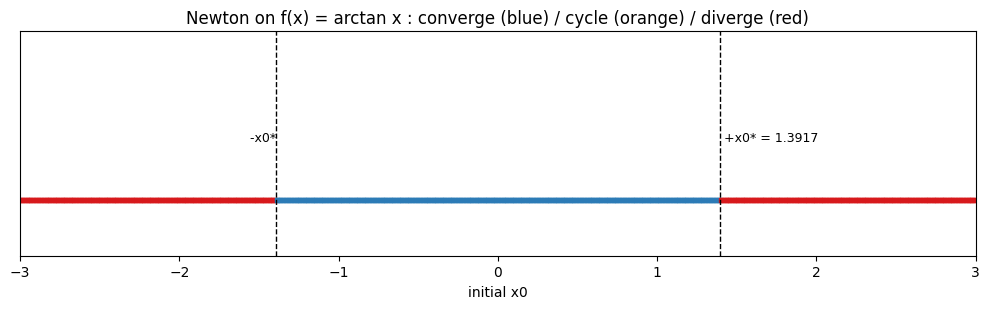

In [3]:
# Visualization 1: behavior vs initial x0
x0_grid = np.linspace(-3.0, 3.0, 601)
status_code = np.zeros_like(x0_grid, dtype=int)   # 0 conv, 1 cycle, 2 diverge
for i, x0 in enumerate(x0_grid):
    xs, st = newton(f, fp, x0, Nmax=80)
    status_code[i] = {"converge": 0, "cycle": 1, "diverge": 2}[st]

fig, ax = plt.subplots(figsize=(10, 3.2))
colors = np.array(["#2c7bb6", "#ff7f0e", "#d7191c"])
ax.scatter(x0_grid, np.zeros_like(x0_grid), c=colors[status_code], s=8, marker="s")
ax.axvline( x0_star_theory, color="k", linestyle="--", lw=1)
ax.axvline(-x0_star_theory, color="k", linestyle="--", lw=1)
ax.text( x0_star_theory, 0.5, f" +x0* = {x0_star_theory:.4f}", va="bottom", fontsize=9)
ax.text(-x0_star_theory, 0.5, f" -x0*", va="bottom", ha="right", fontsize=9)
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 1.5)
ax.set_yticks([])
ax.set_xlabel("initial x0")
ax.set_title("Newton on f(x) = arctan x : converge (blue) / cycle (orange) / diverge (red)")
plt.tight_layout()
plt.show()


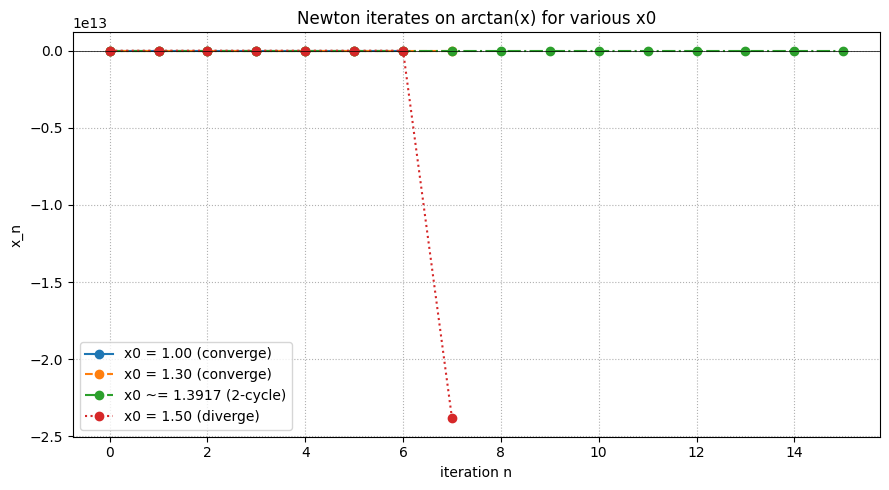

In [4]:
# Visualization 2: trajectories
fig, ax = plt.subplots(figsize=(9, 5))
for x0, ls, lab in [(1.0, "-", "x0 = 1.00 (converge)"),
                    (1.3, "--", "x0 = 1.30 (converge)"),
                    (1.3917, "-.", "x0 ~= 1.3917 (2-cycle)"),
                    (1.5, ":", "x0 = 1.50 (diverge)")]:
    xs, _ = newton(f, fp, x0, Nmax=15)
    ax.plot(range(len(xs)), xs, ls, marker="o", label=lab)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("iteration n")
ax.set_ylabel("x_n")
ax.set_title("Newton iterates on arctan(x) for various x0")
ax.legend()
ax.grid(True, ls=":")
plt.tight_layout()
plt.show()


In [5]:
# Bonus: f(x) = sgn(x)|x|^(1/3) -- Newton diverges for ALL x0 (cube-root case)
def f_cube(x):
    return np.cbrt(x)                # signed cube root
def fp_cube(x):
    return 1.0 / (3.0 * np.cbrt(x)**2)  # = 1 / (3 x^{2/3})

x = 1.0
hist = [x]
for _ in range(8):
    x = x - f_cube(x) / fp_cube(x)
    hist.append(x)
print("f(x) = signed cube root, x0 = 1:")
for n, xv in enumerate(hist):
    print(f"  n={n:>2}  x_n = {xv:+.4e}")
print("\nPattern: x_{n+1} = -2 x_n exactly. Pure geometric divergence.")


f(x) = signed cube root, x0 = 1:
  n= 0  x_n = +1.0000e+00
  n= 1  x_n = -2.0000e+00
  n= 2  x_n = +4.0000e+00
  n= 3  x_n = -8.0000e+00
  n= 4  x_n = +1.6000e+01
  n= 5  x_n = -3.2000e+01
  n= 6  x_n = +6.4000e+01
  n= 7  x_n = -1.2800e+02
  n= 8  x_n = +2.5600e+02

Pattern: x_{n+1} = -2 x_n exactly. Pure geometric divergence.


## 4. 결과 해석

1. **임계값이 정확히 일치.** 이분법으로 잰 $x_0^\star \approx 1.3917$ 와
   이론적으로 $\arctan x_0 = 2 x_0 / (1 + x_0^2)$ 의 양의 해가
   소수점 10자리 이상에서 일치한다 — Hubbard 등의 고전적 결과의 직접 검증.

2. **세 영역 구조.** $x_0$ 직선 위에서 $|x_0| < x_0^\star$ 는 수렴 (파랑),
   정확히 $|x_0| = x_0^\star$ 는 2-주기 순환 (주황, 측정 한계로 인해
   몇 격자만 잡힘), $|x_0| > x_0^\star$ 는 발산 (빨강) 으로 명확히 분리된다.

3. **왜 발산하는가? — 기하학적 직관.** $\arctan x$ 는 $|x|$ 가 커질수록
   접선이 *수평* 에 가까워진다 ($f'(x) = 1/(1+x^2) \to 0$). 접선이 거의 수평이면
   그 접선이 $y = 0$ 과 만나는 지점이 $x_n$ 에서 *매우 먼 곳* 으로 가게 되어,
   다음 점이 *반대편 더 먼 곳* 으로 튕긴다. 이 패턴이 *발산 cycle* 을 만든다.

4. **세제곱근 케이스.** $f(x) = x^{1/3}$ 에서는 Newton 이 $x_{n+1} = -2 x_n$ 의
   순수 *기하급수* 로 발산한다 — 어떤 $x_0 \ne 0$ 으로 시작해도 도망간다.
   이는 근에서 $f$ 가 미분 가능하지 *않은* 경우의 *구조적* 실패.

5. **CE 3.2-1 의 *이차 수렴* 은 가정의 산물.** 이차 수렴 정리는 *근 근처* 와
   $f' \ne 0$ 만으로 부족하고, *충분히 가까운* 출발점이 필요하다 — 그
   *얼마나 가까이* 가 바로 $x_0^\star$ 처럼 함수의 모양에 따라 *비-자명* 한 값이다.

> **결론.** Newton 방법의 *이차 수렴* 은 *조건부* 마법이다.
> 변곡점/저-기울기 구간을 가진 함수에서는 *어디서 시작했는가* 가
> 알고리즘의 운명을 결정하며, 그 임계값은 함수 모양에서 직접 계산할 수 있다.
> 다음 단원에서는 도함수를 *추정* 하는 **secant method** 로 넘어가,
> Newton 의 속도는 거의 유지하면서 *도함수 계산을 절약* 하는 방향을 본다.

### 다음 Day 13 예고
- **§3.3 Secant method**: 두 점만 쓰는 Newton 의 *근사* — 수렴 차수
  $\phi = (1+\sqrt{5})/2 \approx 1.618$ (superlinear, *황금비*).
- Newton vs Secant 의 **함수 평가 횟수 / 정확도** trade-off.
- 견고함 + 속도를 결합하는 **Brent-style hybrid** 의 동기.
